In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from matplotlib.path import Path
import matplotlib.pyplot as plt
import scanpy as sc

from PIL import Image
Image.MAX_IMAGE_PIXELS = None


In [2]:
bdata = sc.read_h5ad('../Example_Data/H1-TXK6Z4X-A1_2um/skin_TXK6Z4X_A1_2um_b2c_qc.h5ad')

In [4]:
bdata.uns['spatial']

{'skin_TXK6Z4X_A1': {'images': {'0.5_mpp_150_buffer': array([[[224, 136, 125],
           [100,  73, 138],
           [123, 101, 187],
           ...,
           [244, 244, 244],
           [244, 245, 244],
           [244, 244, 245]],
   
          [[179, 129, 164],
           [ 88,  78, 151],
           [ 92,  73, 148],
           ...,
           [244, 244, 241],
           [244, 245, 241],
           [244, 242, 242]],
   
          [[161, 118, 172],
           [128,  89, 155],
           [128,  95, 151],
           ...,
           [244, 244, 243],
           [244, 244, 243],
           [243, 241, 244]],
   
          ...,
   
          [[239, 239, 246],
           [240, 241, 241],
           [239, 244, 239],
           ...,
           [241, 238, 241],
           [242, 238, 242],
           [243, 239, 240]],
   
          [[242, 240, 246],
           [242, 242, 243],
           [241, 244, 240],
           ...,
           [239, 233, 240],
           [238, 236, 240],
           [238, 2

== b2c ground truth ==
 scalef (r_x = r_y) : 1.002686
 crop offset (x0,y0): (12070.000, 22368.000)

[OK] ROI full-res vertices: ./roi_check_outputs_b2c_exact/roi_fullres_vertices_from_b2c.csv
[OK] 16um ROI barcodes saved: ./roi_check_outputs_b2c_exact/barcode_16um_in_roi.csv


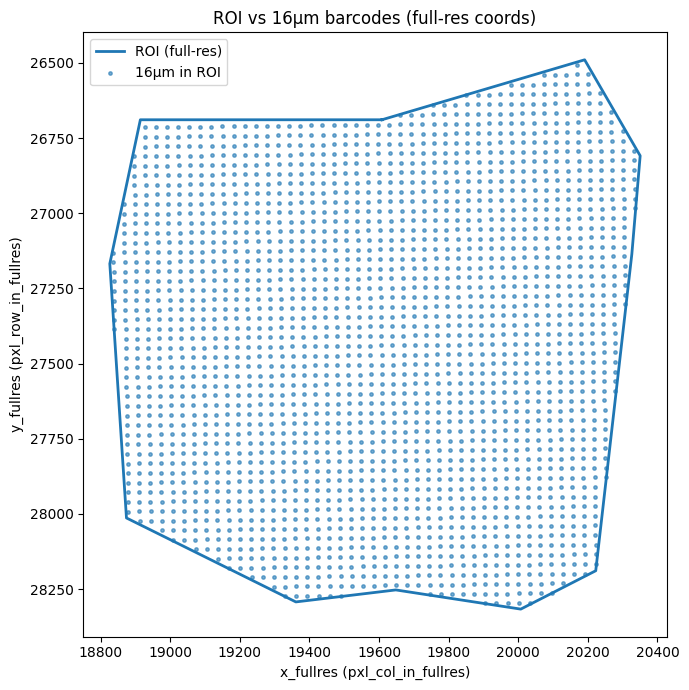

[OK] plot saved: ./roi_check_outputs_b2c_exact/roi_vs_16um_overlay_b2c_exact.png


In [13]:
IMG_KEY         = "0.5_mpp_150_buffer" 
CROPPED_KEY     = "spatial_cropped_150_buffer"
TGT_16UM_PARQUET= "./skin_TXK6Z4X_A1/binned_outputs/square_016um/spatial/tissue_positions.parquet"

OUT_DIR         = "./roi_check_outputs_b2c_exact"
os.makedirs(OUT_DIR, exist_ok=True)


roi_on_processed = [
    (7558.5, 4332.500000000002),
    (6862.5, 4332.500000000002),
    (6774.5, 4812.500000000002),
    (6822.5, 5660.500000000002),
    (7310.5, 5940.500000000002),
    (7598.5, 5900.500000000002),
    (7958.5, 5964.500000000002),
    (8174.5, 5836.500000000002),
    (8278.500000000002, 4780.500000000002),
    (8302.500000000002, 4452.500000000002),
    (8142.5, 4132.500000000002),
]

def get_library_key(adata):
    return list(adata.uns["spatial"].keys())[0]

def get_scalefactor_from_b2c(adata, img_key):
    lib = get_library_key(adata)
    key = f"tissue_{img_key}_scalef"
    return float(adata.uns["spatial"][lib]["scalefactors"][key])

def recover_crop_offset_xy0(adata, cropped_key="spatial_cropped_150_buffer", spatial_key="spatial"):
    if cropped_key not in adata.obsm:
        raise KeyError(f"Could not find {cropped_key}, please check b2c output.")
    S_full = np.asarray(adata.obsm[spatial_key], dtype=float)
    S_crop = np.asarray(adata.obsm[cropped_key], dtype=float)
    D = S_full - S_crop
    x0 = float(np.median(D[:,0]))
    y0 = float(np.median(D[:,1]))
    return x0, y0

def processed_to_fullres(points_uv, x0, y0, scalef):
    """
    image (u,v) = (x0 + u / scalef, y0 + v / scalef)
    """
    arr = np.asarray(points_uv, dtype=float)
    xs = x0 + arr[:,0] / scalef
    ys = y0 + arr[:,1] / scalef
    return np.column_stack([xs, ys])

def select_barcodes_in_polygon(tissue_positions_parquet, polygon_fullres_xy):
    df = pd.read_parquet(tissue_positions_parquet).copy()
    df = df.loc[(df["pxl_row_in_fullres"] >= 0) & (df["pxl_col_in_fullres"] >= 0)]
    pts = np.column_stack([
        df["pxl_col_in_fullres"].to_numpy(dtype=float),
        df["pxl_row_in_fullres"].to_numpy(dtype=float),
    ])
    poly_path = Path(polygon_fullres_xy)
    inside = poly_path.contains_points(pts)
    # barcode finding
    bc_col = "barcode" if "barcode" in df.columns else \
             "Barcode" if "Barcode" in df.columns else \
             "barcodes" if "barcodes" in df.columns else \
             "spot_id" if "spot_id" in df.columns else \
             "barcode_id" if "barcode_id" in df.columns else None
    if bc_col is None:
        raise KeyError(f"Could not find barcode column, existing columns: {list(df.columns)[:20]} ...")

    out = df.loc[inside, [bc_col, "pxl_col_in_fullres", "pxl_row_in_fullres"]].copy()
    out = out.rename(columns={
        bc_col: "barcode",
        "pxl_col_in_fullres": "x_fullres",
        "pxl_row_in_fullres": "y_fullres",
    })
    return out

def main(bdata):
    # read scale factor and crop offset from b2c (ground truth)
    s = get_scalefactor_from_b2c(bdata, IMG_KEY)
    x0, y0 = recover_crop_offset_xy0(bdata, CROPPED_KEY, "spatial")

    print(f"== b2c ground truth ==")
    print(f" scalef (r_x = r_y) : {s:.6f}")
    print(f" crop offset (x0,y0): ({x0:.3f}, {y0:.3f})\n")

    # map processed (u,v) -> full-res (x,y)
    roi_fullres = processed_to_fullres(roi_on_processed, x0, y0, s)

    # save full-res ROI vertices
    roi_fullres_csv = os.path.join(OUT_DIR, "roi_fullres_vertices_from_b2c.csv")
    pd.DataFrame(roi_fullres, columns=["x_fullres", "y_fullres"]).to_csv(roi_fullres_csv, index=False)
    print(f"[OK] ROI full-res vertices: {roi_fullres_csv}")

    # filter barcodes inside ROI
    bc16 = select_barcodes_in_polygon(TGT_16UM_PARQUET, roi_fullres)
    out_csv = os.path.join(OUT_DIR, "barcode_16um_in_roi.csv")
    bc16.to_csv(out_csv, index=False)
    print(f"[OK] 16um ROI barcodes saved: {out_csv}")

    # Plot
    if len(bc16) > 0:
        plt.figure(figsize=(7,7))
        poly = np.vstack([roi_fullres, roi_fullres[0]])
        plt.plot(poly[:,0], poly[:,1], linewidth=2, label="ROI (full-res)")
        plt.scatter(bc16["x_fullres"], bc16["y_fullres"], s=6, alpha=0.6, label="16µm in ROI")
        plt.gca().invert_yaxis()
        plt.xlabel("x_fullres (pxl_col_in_fullres)")
        plt.ylabel("y_fullres (pxl_row_in_fullres)")
        plt.title("ROI vs 16µm barcodes (full-res coords)")
        plt.legend()
        plt.tight_layout()
        plot_path = os.path.join(OUT_DIR, "roi_vs_16um_overlay_b2c_exact.png")
        plt.savefig(plot_path, dpi=160)
        plt.show()
        print(f"[OK] plot saved: {plot_path}")

main(bdata)